# Task 4: Conditional GAN Optuna Search & Full Retraining

Hyperparameter optimization and full-schedule retraining for the style-conditioned face-to-sketch conditional GAN as specified in the assignment.

### Mathematical Formulation
$$\hat{y} = G(x, s), \quad D(x, s, y), \quad D\big(x, s, G(x,s)\big)$$
$$\mathcal{L}_G = \mathcal{L}_{adv} + \lambda_{L1}\,\mathcal{L}_{L1}\big(y, G(x,s)\big)$$

### Optuna Search Space Requirements
As required by the assignment, Optuna tunes:
1. **Generator Learning Rate** ($G\_lr \in [10^{-5}, 10^{-3}]$ log scale)
2. **Discriminator Learning Rate** ($D\_lr \in [10^{-5}, 10^{-3}]$ log scale)
3. **Batch Size** ($B \in \{4, 8, 16\}$)
4. **Base Channel Count** ($\text{base\_channels} \in \{32, 64\}$)
5. **Dropout Rate** ($\text{dropout} \in [0.0, 0.5]$)
6. **Style-Embedding Dimension** ($\text{embed\_dim} \in \{4, 8, 16\}$)
7. **Reconstruction-Loss Weight** ($\lambda_{L1} \in [10.0, 200.0]$)

### Retraining:
Because GAN search uses reduced epochs (15 epochs), the selected winning configuration is retrained on the complete training schedule (40 epochs), saving `task4_generator_final_best.pt`.

In [1]:
# 1. Config
N_TRIALS = 18
OPTUNA_EPOCHS = 20
FULL_TRAIN_EPOCHS = 60
STUDY_NAME = "task4_sharp_cgan_v1"
STORAGE_DB = "sqlite:///task4_sharp_study.db"
SEED = 42


In [2]:
# 2. Imports & Setup
import sys
from pathlib import Path
import yaml
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import optuna

RESEARCH_ROOT = Path("..").resolve()
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

from constants import CONFIGS_ROOT
from src.device_utils import get_device, device_report
from src.datasets import FS2KDataset
from src.models_gan import UNetGenerator, PatchGANDiscriminator, postprocess_sketch
from src.train_loop import train_one_epoch_gan, validate_gan, set_seed
from src.checkpoint_utils import create_checkpoint_dict, save_checkpoint

set_seed(SEED)
device = get_device()


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[device] Using GPU via CUDA: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
# 3. Objective Function
train_dataset = FS2KDataset(mode="train", seed=SEED)
val_dataset = FS2KDataset(mode="val", seed=SEED)


def objective(trial: optuna.Trial) -> float:
    g_lr = trial.suggest_float("g_lr", 1e-5, 5e-4, log=True)
    d_lr = trial.suggest_float("d_lr", 1e-5, 2e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [4, 8, 16])
    base_channels = trial.suggest_categorical("base_channels", [32, 64])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    embed_dim = trial.suggest_categorical("embed_dim", [4, 8, 16])
    lambda_l1 = trial.suggest_float("lambda_l1", 50.0, 200.0)
    lambda_edge = trial.suggest_float("lambda_edge", 5.0, 30.0)
    lambda_ssim = trial.suggest_float("lambda_ssim", 1.0, 15.0)
    residual_refinement = trial.suggest_categorical("residual_refinement", [False, True])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    G = UNetGenerator(
        base_channels=base_channels, embed_dim=embed_dim, dropout=dropout,
        multi_scale_style=True, grayscale_constraint=True,
        residual_refinement=residual_refinement,
    ).to(device)
    D = PatchGANDiscriminator(base_channels=base_channels).to(device)
    optG = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.999))

    best_score = float("inf")
    for epoch in range(1, OPTUNA_EPOCHS + 1):
        train_metrics = train_one_epoch_gan(
            G, D, train_loader, optG, optD, device,
            lambda_l1=lambda_l1, lambda_edge=lambda_edge, lambda_ssim=lambda_ssim,
        )
        val_metrics = validate_gan(G, val_loader, device)
        trial.report(val_metrics["val_score"], step=epoch)
        for key in ("val_l1", "val_ssim", "val_edge", "val_edge_normalized", "val_score"):
            trial.set_user_attr(f"epoch_{epoch}_{key}", float(val_metrics[key]))
        trial.set_user_attr(f"epoch_{epoch}_g_edge", train_metrics["g_edge"])
        best_score = min(best_score, val_metrics["val_score"])
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score


In [4]:
# 4. Run Study & Export Config
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE_DB,
    load_if_exists=True,
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=5),
)
study.optimize(objective, n_trials=N_TRIALS)

print(f"Winning sharp cGAN params: {study.best_params}")
print(f"Best trial #{study.best_trial.number}, composite validation score: {study.best_value:.4f}")

cfg_path = CONFIGS_ROOT / "task4_best_config.yaml"
with open(cfg_path, "w") as f:
    yaml.safe_dump({
        "task": "task4_conditional_gan_sharp_v1",
        "source_notebook": "task4_gan_optuna.ipynb",
        "study_name": STUDY_NAME,
        "best_trial_number": int(study.best_trial.number),
        "best_value": float(study.best_value),
        "selection_metric": "0.4*val_l1 + 0.3*(1-val_ssim) + 0.3*val_edge_normalized",
        "architecture": {
            "generator": "style-conditioned U-Net with multi-scale FiLM and optional residual refinement",
            "multi_scale_style": True,
            "grayscale_constraint": True,
            "discriminator_scales": 2,
        },
        "params": study.best_params,
    }, f, sort_keys=False)
print(f"Exported to {cfg_path}")


[I 2026-10-02 13:01:37,233] Using an existing study with `study_name='task4_sharp_cgan_v1'` instead of creating a new one.


[I 2026-10-02 13:03:57,285] Trial 15 finished with value: 0.34245009638701274 and parameters: {'g_lr': 0.0002871369427942453, 'd_lr': 5.407391927987318e-05, 'batch_size': 16, 'base_channels': 32, 'dropout': 0.15797141661284264, 'embed_dim': 16, 'lambda_l1': 139.02132231833286, 'lambda_edge': 25.06706856335706, 'lambda_ssim': 10.756107750161398, 'residual_refinement': False}. Best is trial 15 with value: 0.34245009638701274.
[I 2026-10-02 13:06:35,536] Trial 17 finished with value: 0.3413029432486577 and parameters: {'g_lr': 0.00022436687074694247, 'd_lr': 4.727631802232209e-05, 'batch_size': 8, 'base_channels': 32, 'dropout': 0.0748933470405406, 'embed_dim': 16, 'lambda_l1': 189.83739580233194, 'lambda_edge': 23.223048937548924, 'lambda_ssim': 10.810375125510829, 'residual_refinement': False}. Best is trial 17 with value: 0.3413029432486577.
[I 2026-10-02 13:07:55,393] Trial 19 finished with value: 0.34325909865130283 and parameters: {'g_lr': 0.00023045118250429974, 'd_lr': 8.798793206

KeyboardInterrupt: 


--- Retraining winning sharp cGAN (60 epochs) ---
{'g_lr': 0.00017385927199418935, 'd_lr': 1.2870111632806593e-05, 'batch_size': 8, 'base_channels': 32, 'dropout': 0.07187242929759668, 'embed_dim': 16, 'lambda_l1': 161.0762806702697, 'lambda_edge': 28.61116031809998, 'lambda_ssim': 13.674710603808691, 'residual_refinement': False}
Epoch 01/60 G-L1=0.2627 G-edge=0.0647 Val-L1=0.2154 Val-SSIM=0.5155 Val-edge=0.4601 Score=0.3695 *Best*


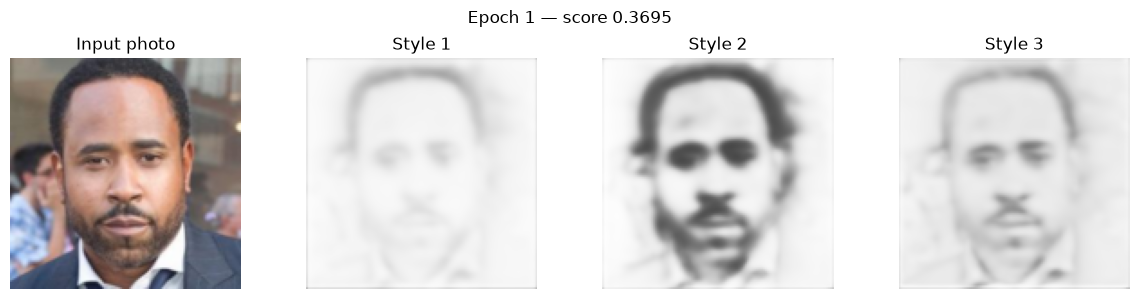

Epoch 02/60 G-L1=0.2148 G-edge=0.0627 Val-L1=0.2008 Val-SSIM=0.5137 Val-edge=0.4712 Score=0.3676 *Best*


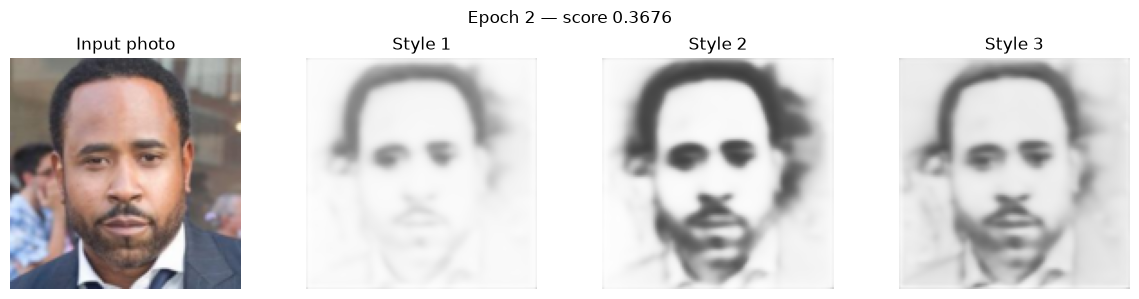

In [ ]:
# 5. Retrain Winning Conditional GAN on Full Schedule
p = study.best_params
print(f"\n--- Retraining winning sharp cGAN ({FULL_TRAIN_EPOCHS} epochs) ---")
print(p)

train_loader = DataLoader(train_dataset, batch_size=p["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=p["batch_size"], shuffle=False, num_workers=2)
winner_G = UNetGenerator(
    base_channels=p["base_channels"], embed_dim=p["embed_dim"], dropout=p["dropout"],
    multi_scale_style=True, grayscale_constraint=True,
    residual_refinement=p["residual_refinement"],
).to(device)
winner_D = PatchGANDiscriminator(base_channels=p["base_channels"]).to(device)
optG = torch.optim.Adam(winner_G.parameters(), lr=p["g_lr"], betas=(0.5, 0.999))
optD = torch.optim.Adam(winner_D.parameters(), lr=p["d_lr"], betas=(0.5, 0.999))

best_score = float("inf")
checkpoint_dir = RESEARCH_ROOT / "checkpoints"
# Fixed photo for a comparable 3-style visual grid at each new best checkpoint.
preview_photo = val_dataset[0][0].unsqueeze(0).to(device)
style_ids = torch.arange(3, device=device)

for epoch in range(1, FULL_TRAIN_EPOCHS + 1):
    metrics = train_one_epoch_gan(
        winner_G, winner_D, train_loader, optG, optD, device,
        lambda_l1=p["lambda_l1"], lambda_edge=p["lambda_edge"], lambda_ssim=p["lambda_ssim"],
    )
    val_metrics = validate_gan(winner_G, val_loader, device)
    is_best = val_metrics["val_score"] < best_score
    if is_best:
        best_score = val_metrics["val_score"]
    ckptG = create_checkpoint_dict(
        winner_G, optG, epoch, val_metrics["val_score"], random_seed=SEED,
        optuna_trial_number=int(study.best_trial.number),
        extra_metadata={
            **p, "selection_metric": "0.4*val_l1 + 0.3*(1-val_ssim) + 0.3*val_edge_normalized",
            "architecture": {
                "generator": "style-conditioned U-Net",
                "multi_scale_style": True,
                "grayscale_constraint": True,
                "residual_refinement": p["residual_refinement"],
                "discriminator_scales": 2,
            },
            **val_metrics,
        },
    )
    save_checkpoint(
        checkpoint_dir, "task4_generator_final", ckptG, is_best=is_best,
        task_name="task4_gan", phase_name="sharp_final",
        device_name=device_report()["device_name"],
    )
    print(
        f"Epoch {epoch:02d}/{FULL_TRAIN_EPOCHS:02d} "
        f"G-L1={metrics['g_l1']:.4f} G-edge={metrics['g_edge']:.4f} "
        f"Val-L1={val_metrics['val_l1']:.4f} Val-SSIM={val_metrics['val_ssim']:.4f} "
        f"Val-edge={val_metrics['val_edge_normalized']:.4f} "
        f"Score={val_metrics['val_score']:.4f} {'*Best*' if is_best else ''}"
    )
    if is_best or epoch % 10 == 0:
        winner_G.eval()
        with torch.no_grad():
            photo_batch = preview_photo.expand(3, -1, -1, -1)
            outputs = winner_G(photo_batch, style_ids).cpu()
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        photo_img = (preview_photo[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
        axes[0].imshow(photo_img); axes[0].set_title("Input photo"); axes[0].axis("off")
        for style_id, output in enumerate(outputs):
            image = (output.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
            axes[style_id + 1].imshow(image)
            axes[style_id + 1].set_title(f"Style {style_id + 1}")
            axes[style_id + 1].axis("off")
        plt.suptitle(f"Epoch {epoch} — score {val_metrics['val_score']:.4f}")
        plt.tight_layout(); plt.show()

print(f"Best composite validation score: {best_score:.4f}")


In [ ]:
# 6. Load Best Checkpoint and Compare Raw / Post-Processed Outputs
import optuna
from src.checkpoint_utils import load_checkpoint

checkpoint_dir = RESEARCH_ROOT / "checkpoints"
config_path = CONFIGS_ROOT / "task4_best_config.yaml"
best_ckpt_path = checkpoint_dir / "task4_generator_final_best.pt"
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)
p = cfg["params"]
architecture = cfg.get("architecture", {})

best_G = UNetGenerator(
    base_channels=p["base_channels"], embed_dim=p["embed_dim"], dropout=p["dropout"],
    multi_scale_style=architecture.get("multi_scale_style", True),
    grayscale_constraint=architecture.get("grayscale_constraint", True),
    residual_refinement=p["residual_refinement"],
).to(device)
ckpt_meta = load_checkpoint(best_ckpt_path, best_G, device=device)
best_G.eval()
print(f"Loaded {best_ckpt_path.name}, epoch {ckpt_meta.get('epoch')}, score {ckpt_meta.get('val_loss'):.4f}")

test_dataset = FS2KDataset(mode="val", seed=SEED)
test_photo = test_dataset[0][0].unsqueeze(0).to(device)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
photo_img = (test_photo[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
for row in range(2):
    axes[row, 0].imshow(photo_img); axes[row, 0].set_title("Input photo"); axes[row, 0].axis("off")
with torch.no_grad():
    for style_id in range(3):
        generated = best_G(test_photo, torch.tensor([style_id], device=device))
        raw_img = (generated[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
        post = postprocess_sketch(generated, contrast_factor=1.30, sharpen=True)
        post_img = (post[0].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
        axes[0, style_id + 1].imshow(raw_img); axes[0, style_id + 1].set_title(f"Raw: Style {style_id + 1}"); axes[0, style_id + 1].axis("off")
        axes[1, style_id + 1].imshow(post_img); axes[1, style_id + 1].set_title(f"Post: Style {style_id + 1}"); axes[1, style_id + 1].axis("off")
plt.suptitle(f"Best checkpoint — epoch {ckpt_meta.get('epoch')}")
plt.tight_layout(); plt.show()
